# Decode Stim1 for all bad models, from untuned neurons

See if you can decode stim 1 identity during the delay period and during stim2

We can try this first:
- Train SVM decoder using only correct trials (firing rates). I would maybe use average firing rates from the first half of the delay period here. We can play around with the time window here.
- Next test the decoder on correct trials (generate another set of correct trials). (Use 2nd half of delay, and stim2)
- Test the decoder on incorrect trials (again use the second half of the delay window, and stim2).

We would expect for the decoder to have good perf when tested on correct trials and poor perf on incorrect trials.

DO FOR UNTUNED NEURONS, CALCULATED FROM SPIKES

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd
import concurrent.futures

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

from sklearn import svm

2025-05-26 12:27:29.784658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 12:27:29.794099: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-26 12:27:29.803354: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-26 12:27:29.806112: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 12:27:29.814350: I tensorflow/core/platform/cpu_feature_guar

## Get bad models

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)
# 

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [3]:
# get list of models with performance btwn 60-80%

bad_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.6 and np.mean(trial_perfs) < 0.8:
        bad_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, bad model # {len(bad_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has performance 0.679, bad model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has performance 0.781, bad model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has performance 0.683, bad model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has performance 0.644, bad model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has performance 0.654, bad model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has performance 0.782, bad model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has performance 0.763, bad model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has performance 0.648, bad model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has performance 0.743, bad model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has performance 0.757, bad model # 10
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoi

## Loop thru bad models and do decoding

### edit function to take in cell indices of interest (eg untuned, exc, inh)

In [4]:
import concurrent.futures


def decode_model(model_name, cell_subset):
    print(f'Starting model: {model_name}')
    
    # Load data (your existing code)
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                       load_LFP=False, load_spikes=False, load_rates=True)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
    times_ms, _, _ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

    # get untuned idxs
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)
    untuned_ind = np.where(np.isnan(tuning))[0]
    n_cells = len(tuning)
    
    # get exc and inh labels
    exc_ind, inh_ind = ld.get_celltype_label(model_name)

    if cell_subset == 'exc':
        cell_inds = exc_ind
    elif cell_subset == 'inh':
        cell_inds = inh_ind
    elif cell_subset == 'untuned':
        cell_inds = untuned_ind
    elif cell_subset == 'tuned':
        cell_inds = np.setdiff1d(np.arange(n_cells), untuned_ind)
    elif cell_subset == 'all':
        cell_inds = np.arange(n_cells)
    else:
        print('Invalid cell subset. Please choose from "exc", "inh", "untuned", or "all". You chose: ', cell_subset)
        return None

    rates_data = rates_data[:, cell_inds, :]  # Select the subset of cells

    n_iter = 100
    n_cv = 10

    # train decoder

    acc_corr_delay2 = np.zeros(n_iter)
    acc_corr_delay2_null = np.zeros(n_iter)
    acc_incorr_delay2 = np.zeros(n_iter)
    acc_incorr_delay2_null = np.zeros(n_iter)
    acc_corr_stim2 = np.zeros(n_iter)
    acc_corr_stim2_null = np.zeros(n_iter)
    acc_incorr_stim2 = np.zeros(n_iter)
    acc_incorr_stim2_null = np.zeros(n_iter)

    correct_idx = np.where(trial_perfs == 1)[0]
    incorrect_idx = np.where(trial_perfs == 0)[0]

    corr_labels = trial_labels[correct_idx] # get labels for correct trials
    n_corr_pos = np.sum(corr_labels[:, 0] == 1)
    n_corr_neg = np.sum(corr_labels[:, 0] == -1)
    n_corr_sample = int(np.min([n_corr_pos, n_corr_neg]))  # balanced

    # balance incorrect trials too
    incorr_labels = trial_labels[incorrect_idx] # get labels for incorrect trials
    n_incorr_pos = np.sum(incorr_labels[:, 0] == 1)
    n_incorr_neg = np.sum(incorr_labels[:, 0] == -1)
    n_incorr_sample = int(np.min([n_incorr_pos, n_incorr_neg]))  # balanced
    if n_incorr_sample == 0:
        return None  # or return {}, then filter later


    # delay period segments
    delay_times_half1 = np.arange(times_ms['stim1_off'], times_ms['stim1_off'] + np.round(times_ms['delay']/2)).astype(int)
    delay_times_half2 = np.arange(times_ms['stim1_off'] + np.round(times_ms['delay']/2), times_ms['stim2_on']).astype(int)
    stim2_times = np.arange(times_ms['stim2_on'], times_ms['stim2_off']).astype(int)

    for i in range(n_iter):

        # Get pools of correct trials for each class
        pos_corr_pool = correct_idx[trial_labels[correct_idx, 0] == 1]
        neg_corr_pool = correct_idx[trial_labels[correct_idx, 0] == -1]
        pos_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == 1]
        neg_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == -1]

        # Balanced sampling
        corr_sample_pos = np.random.choice(pos_corr_pool, n_corr_sample, replace=True)
        corr_sample_neg = np.random.choice(neg_corr_pool, n_corr_sample, replace=True)
        corr_sample = np.concatenate((corr_sample_pos, corr_sample_neg))
        incorr_sample_pos = np.random.choice(pos_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample_neg = np.random.choice(neg_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample = np.concatenate((incorr_sample_pos, incorr_sample_neg))

        n_splits = 2
        n_test = int(np.floor(len(corr_sample) / n_splits))
        n_train = len(corr_sample) - n_test

        for j in range(n_cv):
            sample_indices = np.arange(len(corr_sample))
            test_indices = np.random.choice(sample_indices, n_test, replace=False)
            train_indices = np.setdiff1d(sample_indices, test_indices)

            test_idx = corr_sample[test_indices]
            train_idx = corr_sample[train_indices]

            # get labels for test and train trials
            train_labels = trial_labels[train_idx,0]
            test_labels = trial_labels[test_idx,0]

            # get data for test and train trials  
            train_data = np.mean(rates_data[delay_times_half1, :,:], axis=0) # train on first half delay of one set 
            train_data = train_data[:, train_idx].T # train on first half delay of one set
            test_data_delay2 = np.mean(rates_data[delay_times_half2, :,:], axis=0) # test on second half delay 
            test_data_stim2 = np.mean(rates_data[stim2_times, :,:], axis=0) # test on stim2 period

            # fit SVM to training data
            clf = svm.SVC(kernel='linear', C=1.0)
            clf.fit(train_data, train_labels)
            clf_null = svm.SVC(kernel='linear', C=1.0) # null w shuffled labels
            train_labels_null = np.random.permutation(train_labels) # shuffle labels
            clf_null.fit(train_data, train_labels_null)

            # predict on test data, from correct delay half2
            test_data_corr = test_data_delay2[:, test_idx].T # test on second half delay of other set of corrects
            pred_labels_corr2 = clf.predict(test_data_corr)
            pred_labels_corr2_null = clf_null.predict(test_data_corr)
            acc_corr_delay2[i] += np.mean(pred_labels_corr2 == test_labels)
            acc_corr_delay2_null[i] += np.mean(pred_labels_corr2_null == test_labels)
    
            # predict on test data, from incorrect delay half2
            test_data_incorr = test_data_delay2[:, incorr_sample].T # test on second half delay of incorrects
            pred_labels_incorr2 = clf.predict(test_data_incorr)
            pred_labels_incorr2_null = clf_null.predict(test_data_incorr)
            acc_incorr_delay2[i] += np.mean(pred_labels_incorr2 == trial_labels[incorr_sample,0])
            acc_incorr_delay2_null[i] += np.mean(pred_labels_incorr2_null == trial_labels[incorr_sample,0])

            # predict on test data, from correct stim2
            test_data_corr = test_data_stim2[:, test_idx].T # test on stim2 period of other set of corrects
            pred_labels_corr2 = clf.predict(test_data_corr)
            pred_labels_corr2_null = clf_null.predict(test_data_corr)
            acc_corr_stim2[i] += np.mean(pred_labels_corr2 == test_labels)
            acc_corr_stim2_null[i] += np.mean(pred_labels_corr2_null == test_labels)
    
            # predict on test data, from incorrect stim2
            test_data_incorr = test_data_stim2[:, incorr_sample].T # test on stim2 period of incorrects
            pred_labels_incorr2 = clf.predict(test_data_incorr)
            pred_labels_incorr2_null = clf_null.predict(test_data_incorr)
            acc_incorr_stim2[i] += np.mean(pred_labels_incorr2 == trial_labels[incorr_sample,0])
            acc_incorr_stim2_null[i] += np.mean(pred_labels_incorr2_null == trial_labels[incorr_sample,0])

        # divide by n_cv
        acc_corr_delay2[i] /= n_cv
        acc_corr_delay2_null[i] /= n_cv
        acc_incorr_delay2[i] /= n_cv
        acc_incorr_delay2_null[i] /= n_cv
        acc_corr_stim2[i] /= n_cv
        acc_corr_stim2_null[i] /= n_cv
        acc_incorr_stim2[i] /= n_cv
        acc_incorr_stim2_null[i] /= n_cv
        
    return {
        'model_name': model_name,
        'acc_corr_delay2': acc_corr_delay2,
        'acc_incorr_delay2': acc_incorr_delay2,
        'acc_corr_delay2_null': acc_corr_delay2_null,
        'acc_incorr_delay2_null': acc_incorr_delay2_null,
        'acc_corr_stim2': acc_corr_stim2,
        'acc_incorr_stim2': acc_incorr_stim2,
        'acc_corr_stim2_null': acc_corr_stim2_null,
        'acc_incorr_stim2_null': acc_incorr_stim2_null
    }



#### untuned

In [5]:
cell_subsets = ["untuned" for i in range(len(bad_models))]

In [ ]:
# Use ProcessPoolExecutor to parallelize across models
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(decode_model, bad_models, cell_subsets))

results = [r for r in results if r is not None]  # Filter out None results

# Combine and save
decoding_results_untuned_df = pd.DataFrame(results)
decoding_results_untuned_df.to_pickle(f'/results_data/decode_stim1_untuned_results_bad_models_{condn_phrase}{condn_num}.pkl')

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_123338


Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204500Starting model: Task_xor_N_20

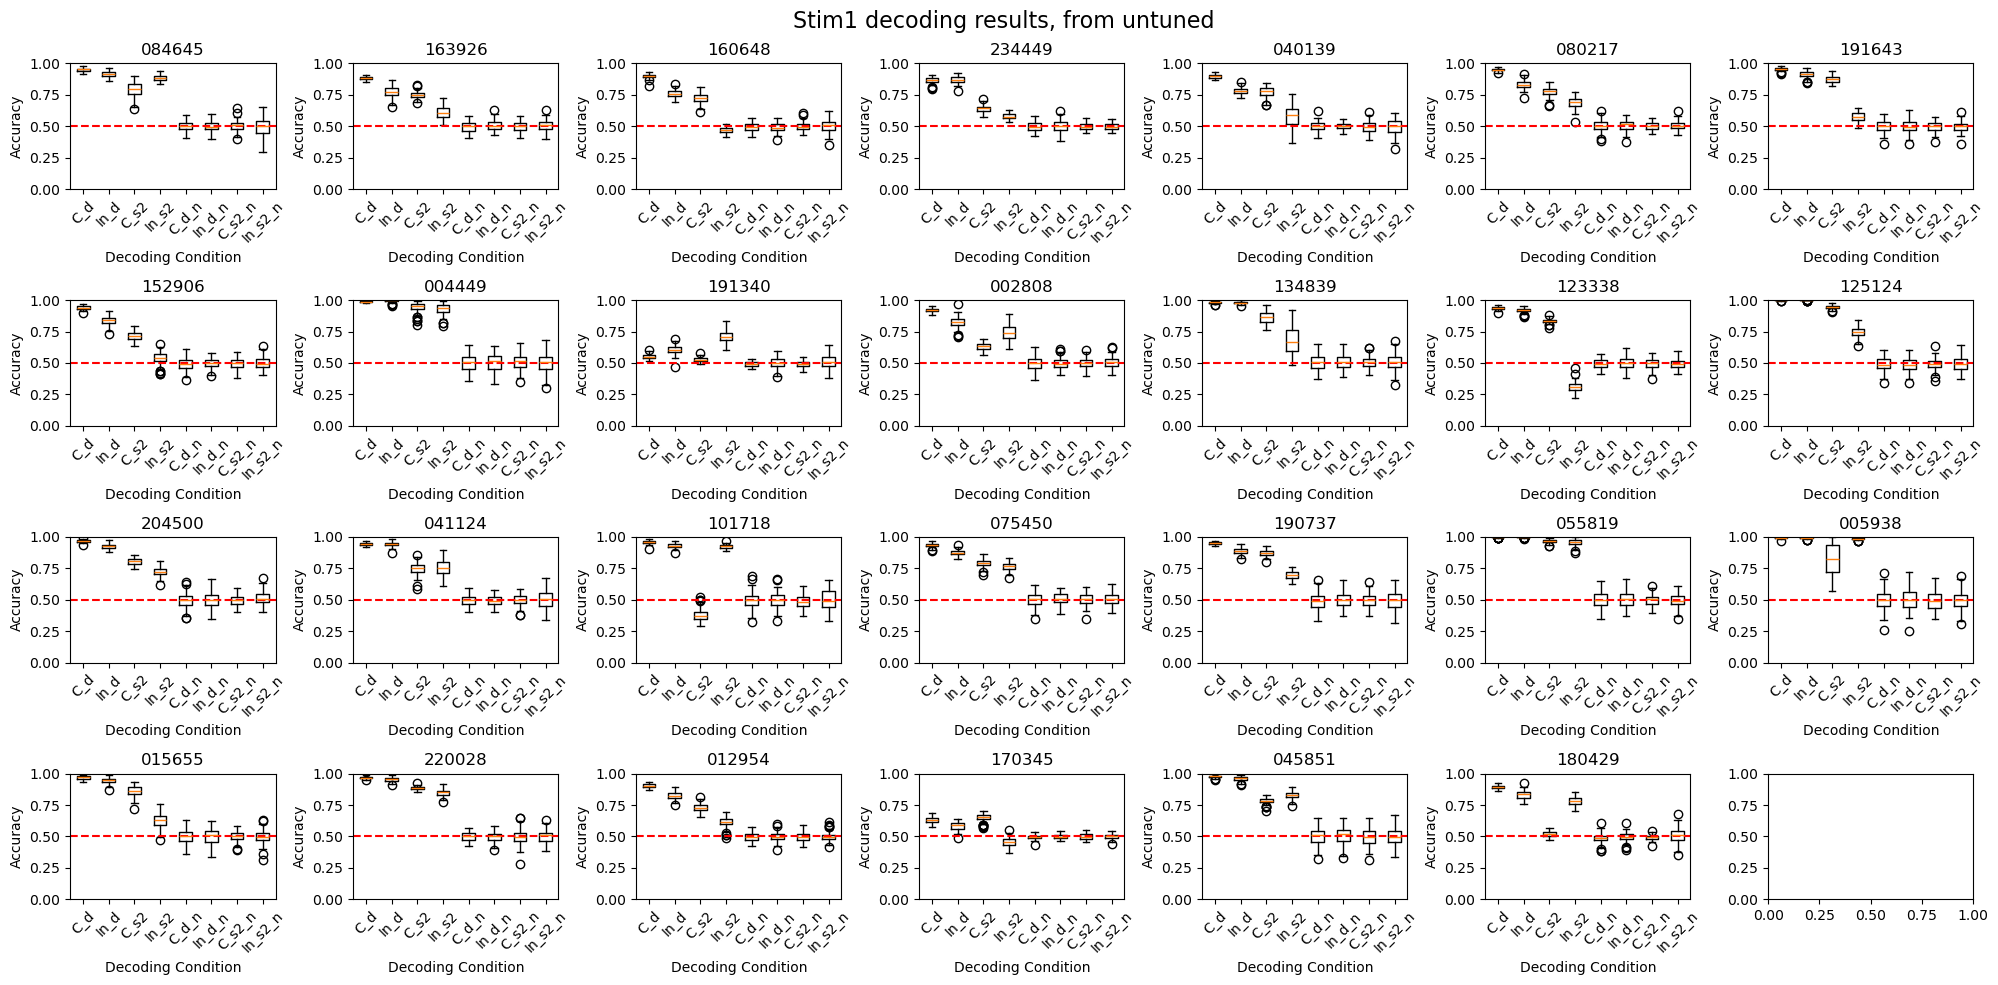

In [7]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 decoding results, from untuned', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_untuned_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # plot 
    axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2, acc_corr_delay2_null, acc_incorr_delay2_null, acc_corr_stim2_null, acc_incorr_stim2_null])
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0, 1)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
    # axs[i_model].legend()
    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

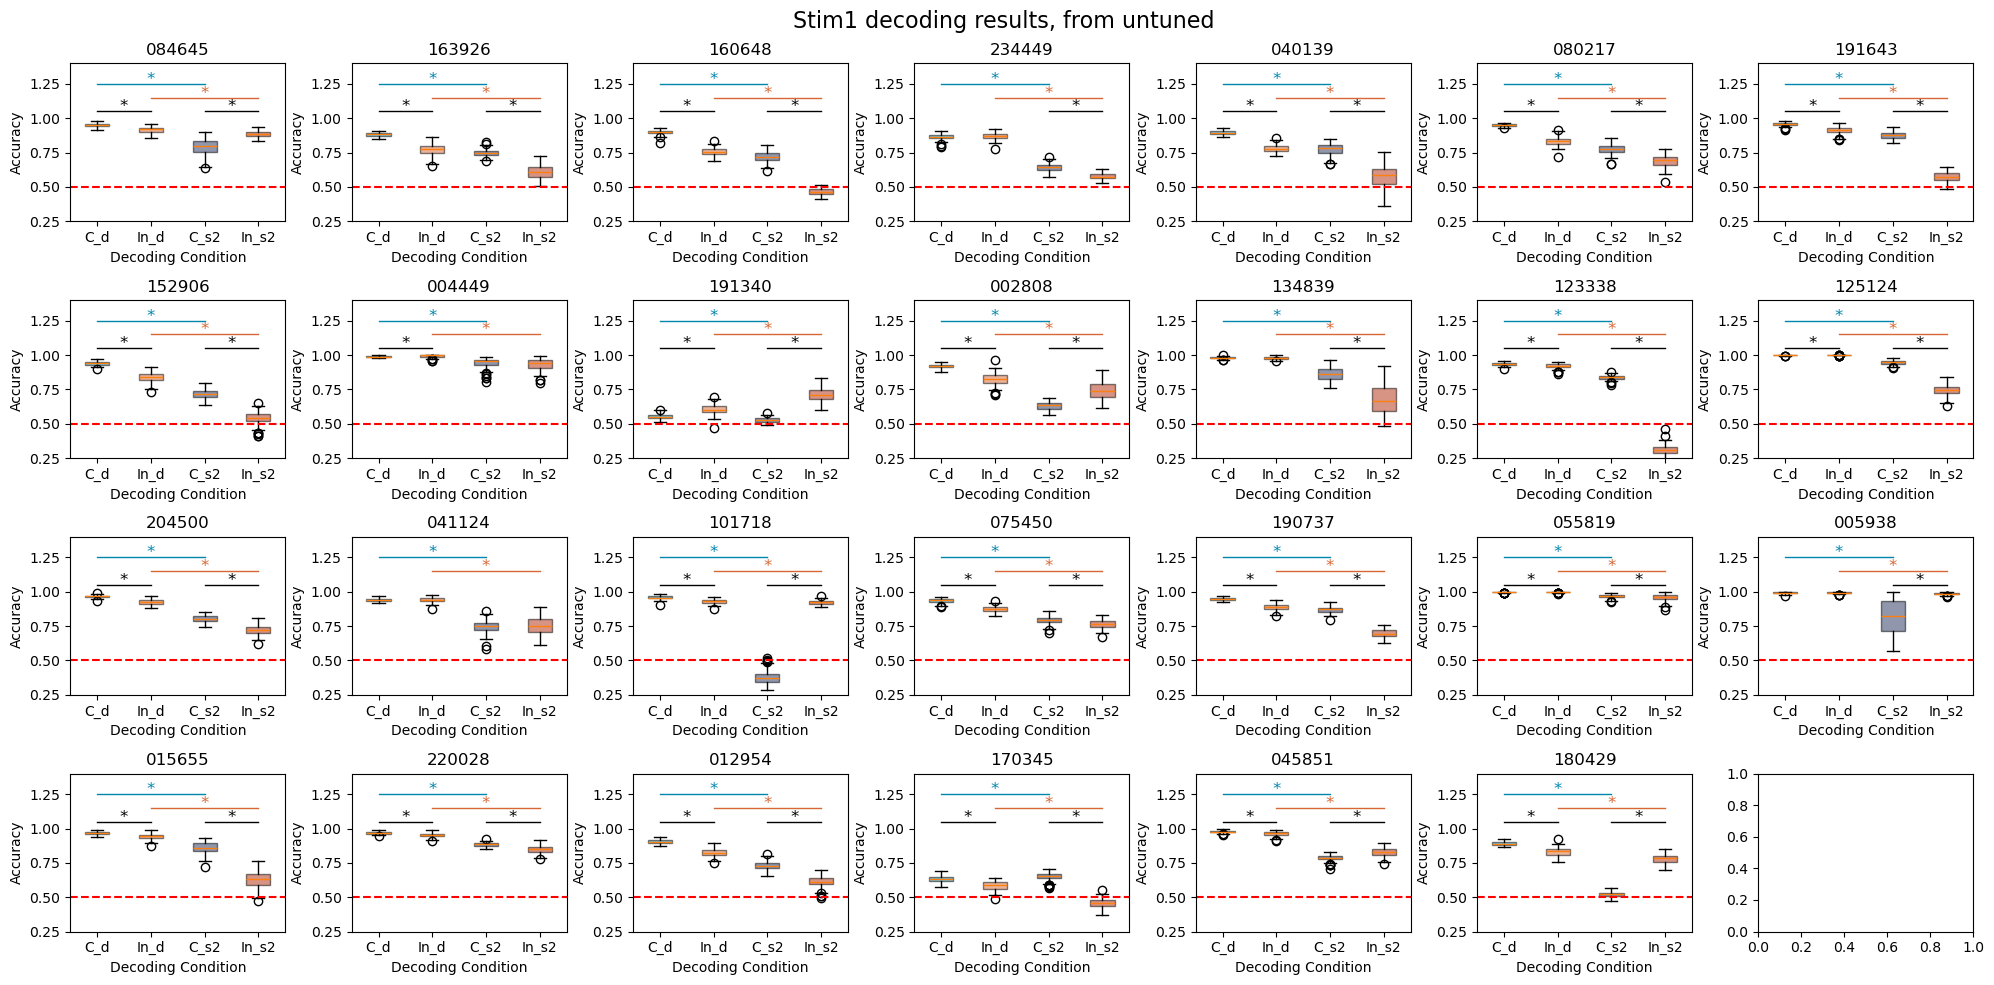

In [8]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 decoding results, from untuned', fontsize=16)
axs = axs.flatten()

colors = ['#0085AD','#D76735','#222F5B','#B12A0C']

for i_model, model_data in decoding_results_untuned_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # do stats
    corr_time_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_corr_stim2)[1]
    incorr_time_p = scipy.stats.mannwhitneyu(acc_incorr_delay2, acc_incorr_stim2)[1]
    delay_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_incorr_delay2)[1]
    stim2_p = scipy.stats.mannwhitneyu(acc_corr_stim2, acc_incorr_stim2)[1]

    # plot 
    bp = axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2], patch_artist=True)
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0.25, 1.4)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2'])
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])  # Set the face color of the box
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)  # Set transparency (optional)
    
    # Add significance stars and p-values
    if corr_time_p < 0.05:
        axs[i_model].text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
        # axs[i_model].text(2, 1.2, f'p={corr_time_p:.3f}', fontsize=10, color=colors[0], ha='center')
        axs[i_model].plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
    if incorr_time_p < 0.05:
        axs[i_model].text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
        # axs[i_model].text(3, 1.2, f'p={incorr_time_p:.3f}', fontsize=10, color=colors[1], ha='center')
        axs[i_model].plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
    if delay_p < 0.05:
        axs[i_model].text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([1,2], [1.05, 1.05], color='black', lw=1)
    if stim2_p < 0.05:
        axs[i_model].text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([3,4], [1.05, 1.05], color='black', lw=1)

    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

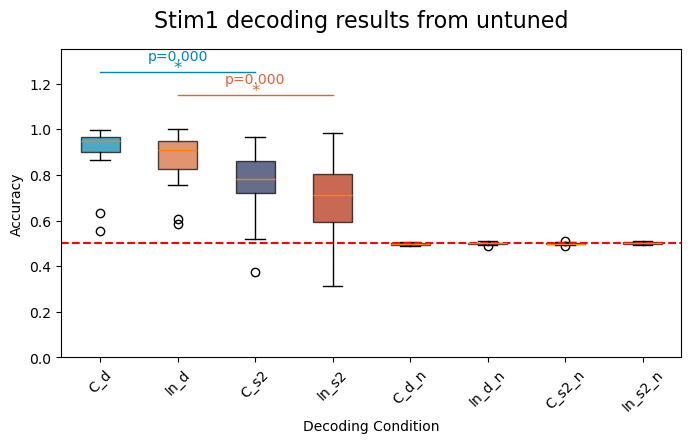

In [9]:
# now take mean and aggregate across models and do boxplot

corr_delay2_means = np.zeros(len(decoding_results_untuned_df))
incorr_delay2_means = np.zeros(len(decoding_results_untuned_df))
corr_delay2_null_means = np.zeros(len(decoding_results_untuned_df))
incorr_delay2_null_means = np.zeros(len(decoding_results_untuned_df))
corr_stim2_means = np.zeros(len(decoding_results_untuned_df))
incorr_stim2_means = np.zeros(len(decoding_results_untuned_df))
corr_stim2_null_means = np.zeros(len(decoding_results_untuned_df))
incorr_stim2_null_means = np.zeros(len(decoding_results_untuned_df))

for i_model, model_data in decoding_results_untuned_df.iterrows():
    corr_delay2_means[i_model] = np.mean(model_data['acc_corr_delay2'])
    incorr_delay2_means[i_model] = np.mean(model_data['acc_incorr_delay2'])
    corr_delay2_null_means[i_model] = np.mean(model_data['acc_corr_delay2_null'])
    incorr_delay2_null_means[i_model] = np.mean(model_data['acc_incorr_delay2_null'])
    corr_stim2_means[i_model] = np.mean(model_data['acc_corr_stim2'])
    incorr_stim2_means[i_model] = np.mean(model_data['acc_incorr_stim2'])
    corr_stim2_null_means[i_model] = np.mean(model_data['acc_corr_stim2_null'])
    incorr_stim2_null_means[i_model] = np.mean(model_data['acc_incorr_stim2_null'])

# do stats
corr_delay2_p = scipy.stats.mannwhitneyu(corr_delay2_means, corr_stim2_means)[1]
incorr_delay2_p = scipy.stats.mannwhitneyu(incorr_delay2_means, incorr_stim2_means)[1]
delay_p = scipy.stats.mannwhitneyu(corr_delay2_means, incorr_delay2_means)[1]
stim2_p = scipy.stats.mannwhitneyu(corr_stim2_means, incorr_stim2_means)[1]

# plot
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'Stim1 decoding results from untuned', fontsize=16)
bp = axs.boxplot([corr_delay2_means, incorr_delay2_means, corr_stim2_means, incorr_stim2_means, corr_delay2_null_means, incorr_delay2_null_means, corr_stim2_null_means, incorr_stim2_null_means], 
patch_artist=True)
for k, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[k%4])  # Set the face color of the box
    box.set_edgecolor('black')  # Optionally set edge color
    box.set_alpha(0.7)  # Set transparency (optional)

# Add significance stars and p-values
if corr_delay2_p < 0.05:
    axs.text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
    axs.text(2, 1.3, f'p={corr_delay2_p:.3f}', fontsize=10, color=colors[0], ha='center')
    axs.plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
if incorr_delay2_p < 0.05:
    axs.text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
    axs.text(3, 1.2, f'p={incorr_delay2_p:.3f}', fontsize=10, color=colors[1], ha='center')
    axs.plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
if delay_p < 0.05:
    axs.text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([1,2], [1.05, 1.05], color='black', lw=1)
if stim2_p < 0.05:
    axs.text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([3,4], [1.05, 1.05], color='black', lw=1)
axs.axhline(y=0.5, color='r', linestyle='--')
axs.set_ylabel('Accuracy')
axs.set_ylim(0, 1.35)
axs.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
axs.set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
axs.set_xlabel('Decoding Condition');

#### tuned

In [10]:
cell_subsets = ["tuned" for i in range(len(bad_models))]

In [11]:
# Use ProcessPoolExecutor to parallelize across models
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(decode_model, bad_models, cell_subsets))

results = [r for r in results if r is not None]  # Filter out None results

# Combine and save
decoding_results_tuned_df = pd.DataFrame(results)
decoding_results_tuned_df.to_pickle(f'/results_data/decode_stim1_tuned_results_bad_models{condn_phrase}{condn_num}.pkl')

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_123338Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_134839

Starting model: Task_xor_N_200_Ta

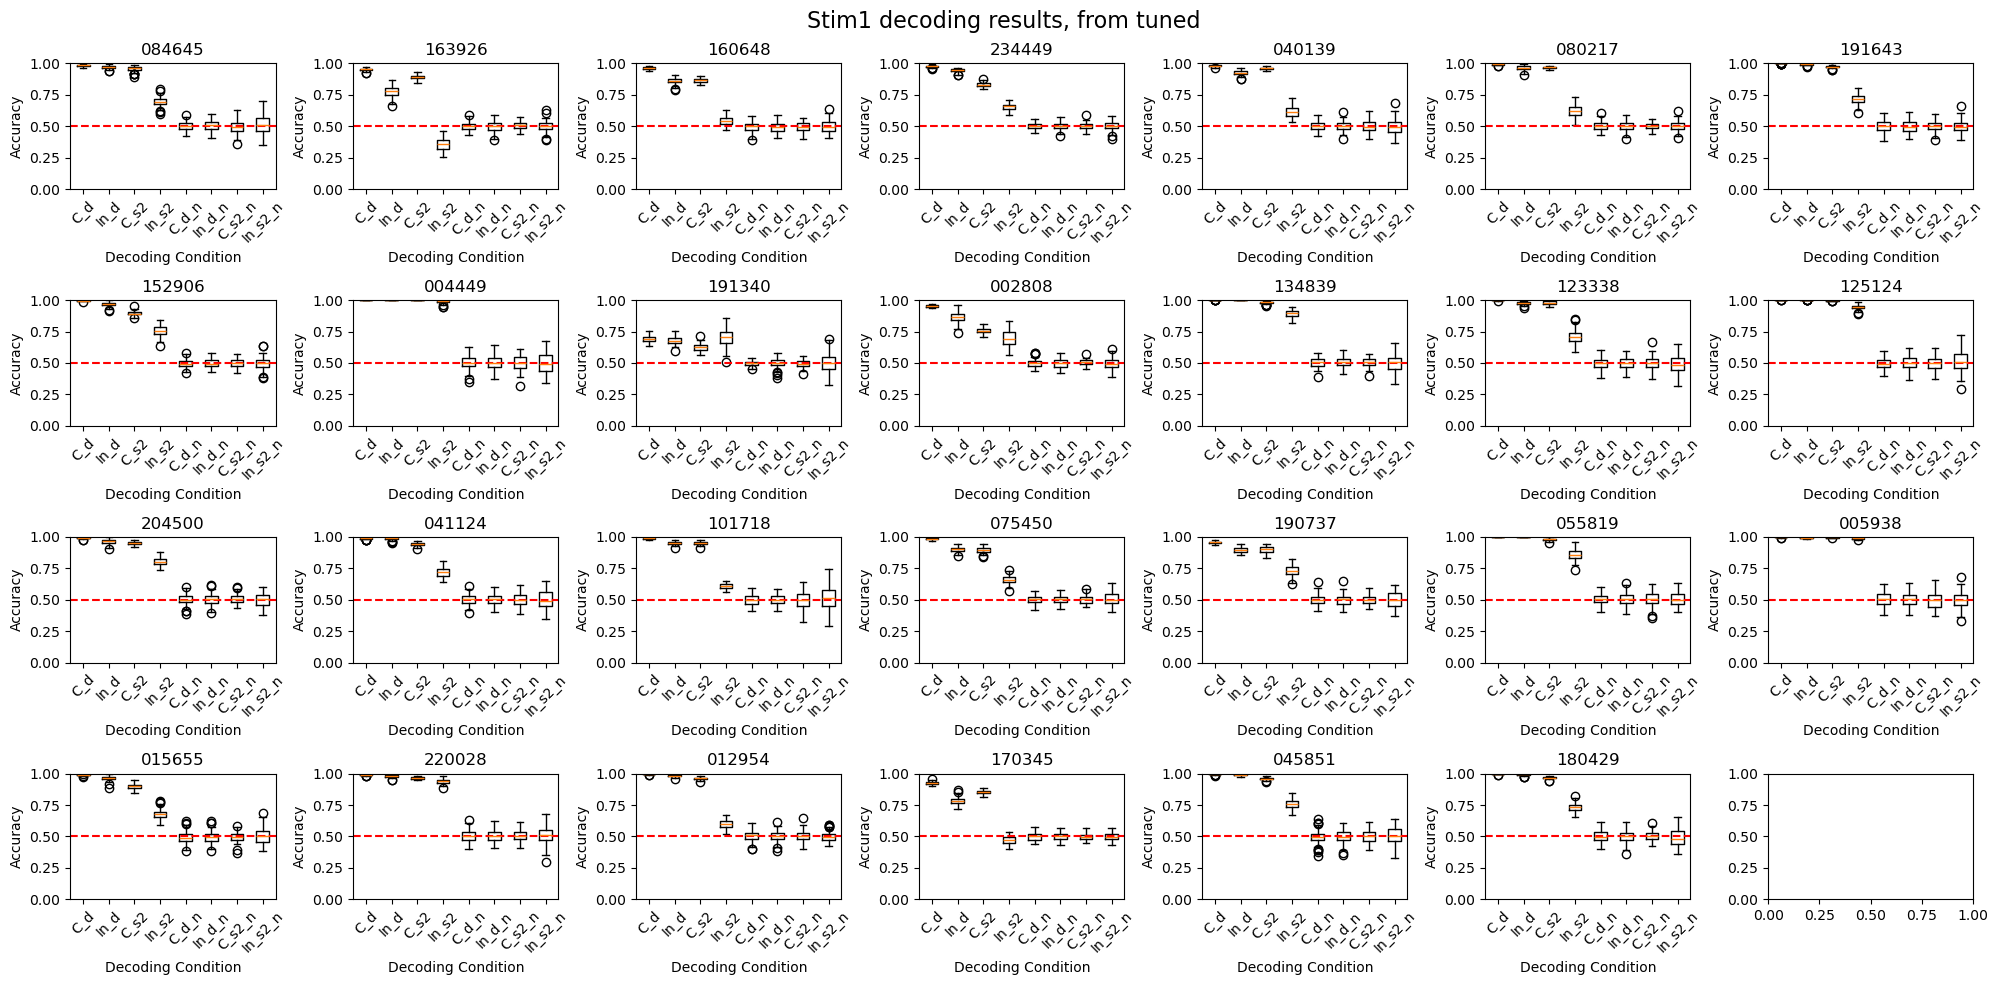

In [12]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 decoding results, from tuned', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_tuned_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # plot 
    axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2, acc_corr_delay2_null, acc_incorr_delay2_null, acc_corr_stim2_null, acc_incorr_stim2_null])
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0, 1)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
    # axs[i_model].legend()
    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

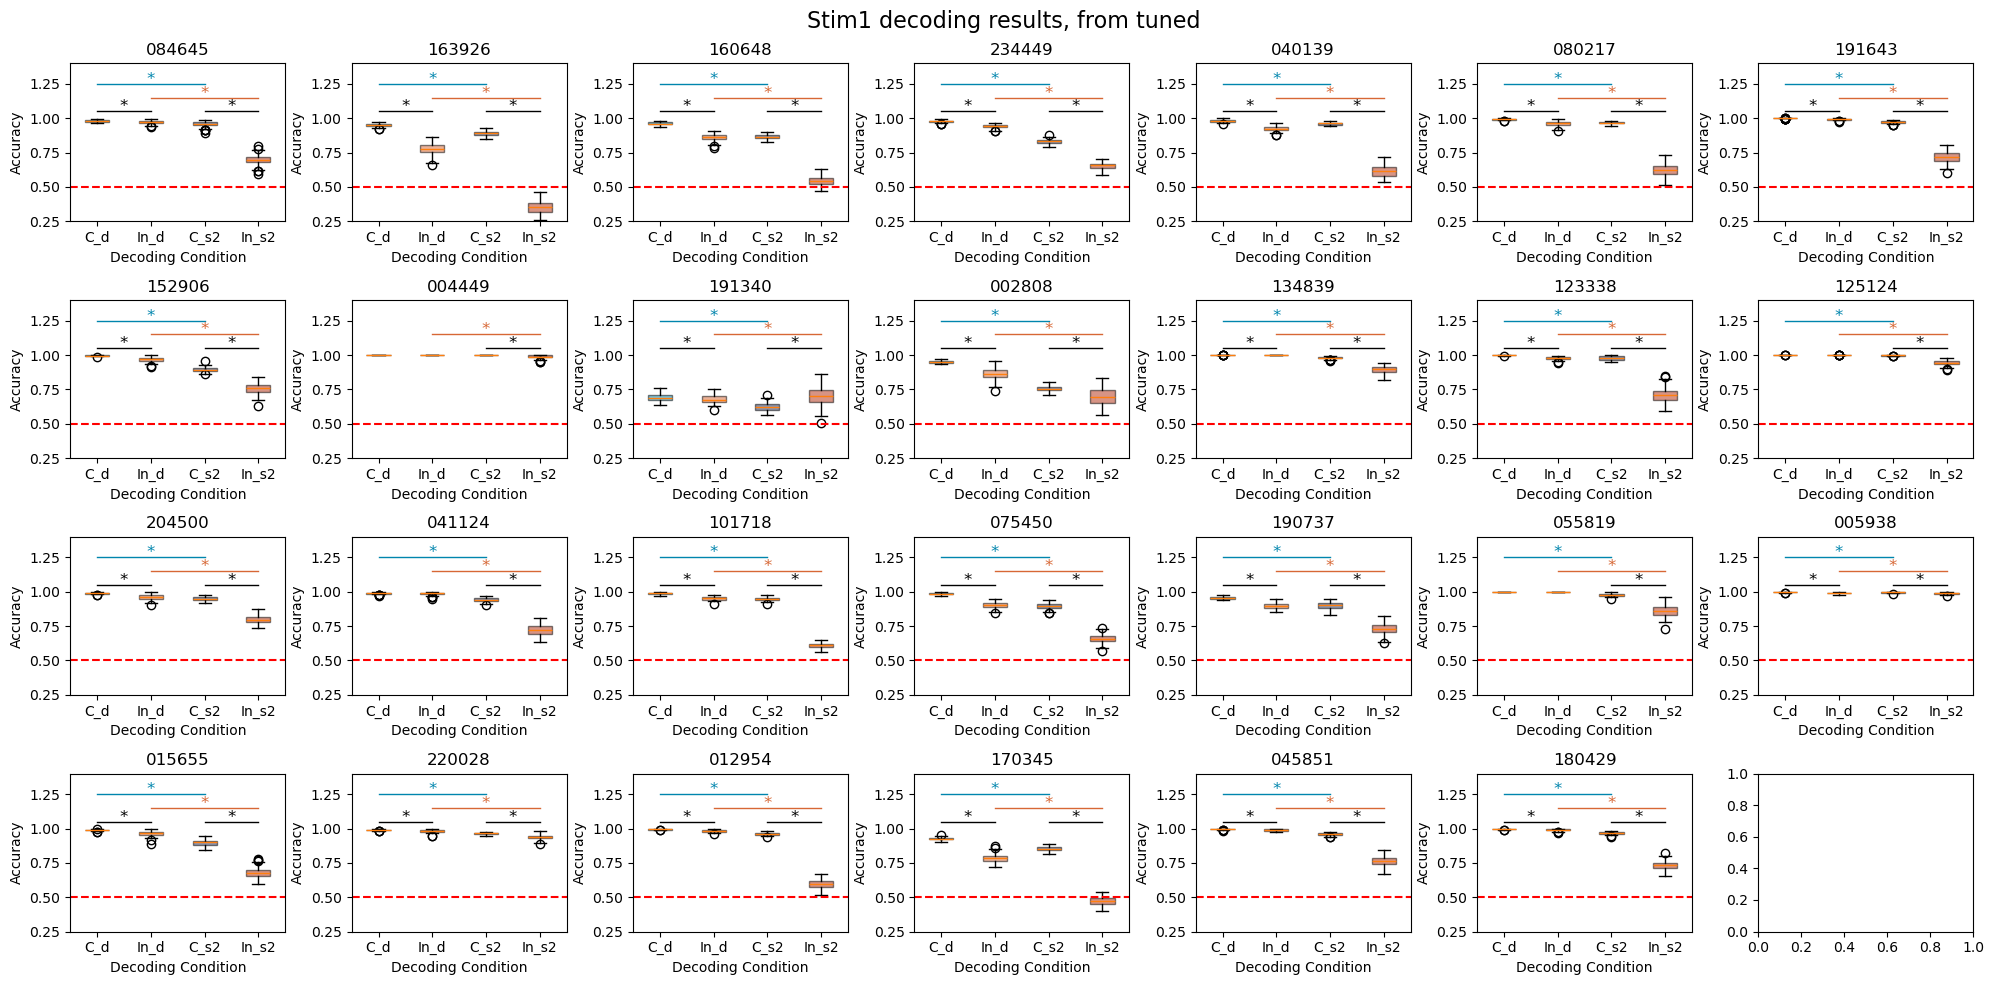

In [13]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim1 decoding results, from tuned', fontsize=16)
axs = axs.flatten()

colors = ['#0085AD','#D76735','#222F5B','#B12A0C']

for i_model, model_data in decoding_results_tuned_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr_delay2 = model_data['acc_corr_delay2']
    acc_incorr_delay2 = model_data['acc_incorr_delay2']
    acc_corr_delay2_null = model_data['acc_corr_delay2_null']
    acc_incorr_delay2_null = model_data['acc_incorr_delay2_null']
    acc_corr_stim2 = model_data['acc_corr_stim2']
    acc_incorr_stim2 = model_data['acc_incorr_stim2']
    acc_corr_stim2_null = model_data['acc_corr_stim2_null']
    acc_incorr_stim2_null = model_data['acc_incorr_stim2_null']

    # do stats
    corr_time_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_corr_stim2)[1]
    incorr_time_p = scipy.stats.mannwhitneyu(acc_incorr_delay2, acc_incorr_stim2)[1]
    delay_p = scipy.stats.mannwhitneyu(acc_corr_delay2, acc_incorr_delay2)[1]
    stim2_p = scipy.stats.mannwhitneyu(acc_corr_stim2, acc_incorr_stim2)[1]

    # plot 
    bp = axs[i_model].boxplot([acc_corr_delay2, acc_incorr_delay2, acc_corr_stim2, acc_incorr_stim2], patch_artist=True)
    axs[i_model].axhline(y=0.5, color='r', linestyle='--')
    axs[i_model].set_title(model_name)
    axs[i_model].set_ylabel('Accuracy')
    axs[i_model].set_ylim(0.25, 1.4)
    axs[i_model].set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2'])
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])  # Set the face color of the box
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)  # Set transparency (optional)
    
    # Add significance stars and p-values
    if corr_time_p < 0.05:
        axs[i_model].text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
        # axs[i_model].text(2, 1.2, f'p={corr_time_p:.3f}', fontsize=10, color=colors[0], ha='center')
        axs[i_model].plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
    if incorr_time_p < 0.05:
        axs[i_model].text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
        # axs[i_model].text(3, 1.2, f'p={incorr_time_p:.3f}', fontsize=10, color=colors[1], ha='center')
        axs[i_model].plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
    if delay_p < 0.05:
        axs[i_model].text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([1,2], [1.05, 1.05], color='black', lw=1)
    if stim2_p < 0.05:
        axs[i_model].text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
        # axs[i_model].text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
        axs[i_model].plot([3,4], [1.05, 1.05], color='black', lw=1)

    axs[i_model].set_xlabel('Decoding Condition')
    axs[i_model].set_title(model_name)

plt.tight_layout()
plt.show()
    

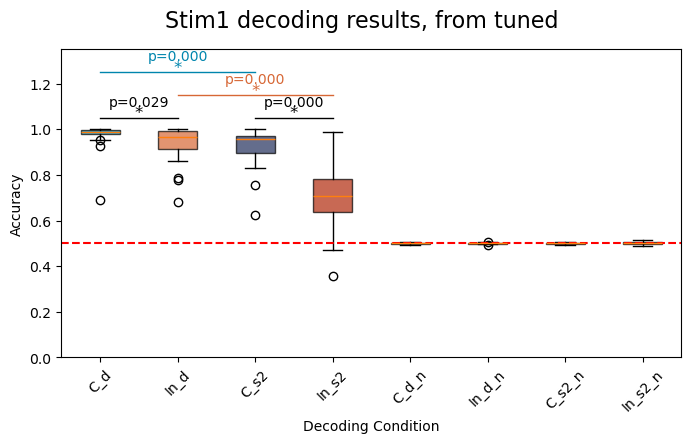

In [14]:
# now take mean and aggregate across models and do boxplot

corr_delay2_means = np.zeros(len(decoding_results_tuned_df))
incorr_delay2_means = np.zeros(len(decoding_results_tuned_df))
corr_delay2_null_means = np.zeros(len(decoding_results_tuned_df))
incorr_delay2_null_means = np.zeros(len(decoding_results_tuned_df))
corr_stim2_means = np.zeros(len(decoding_results_tuned_df))
incorr_stim2_means = np.zeros(len(decoding_results_tuned_df))
corr_stim2_null_means = np.zeros(len(decoding_results_tuned_df))
incorr_stim2_null_means = np.zeros(len(decoding_results_tuned_df))

for i_model, model_data in decoding_results_tuned_df.iterrows():
    corr_delay2_means[i_model] = np.mean(model_data['acc_corr_delay2'])
    incorr_delay2_means[i_model] = np.mean(model_data['acc_incorr_delay2'])
    corr_delay2_null_means[i_model] = np.mean(model_data['acc_corr_delay2_null'])
    incorr_delay2_null_means[i_model] = np.mean(model_data['acc_incorr_delay2_null'])
    corr_stim2_means[i_model] = np.mean(model_data['acc_corr_stim2'])
    incorr_stim2_means[i_model] = np.mean(model_data['acc_incorr_stim2'])
    corr_stim2_null_means[i_model] = np.mean(model_data['acc_corr_stim2_null'])
    incorr_stim2_null_means[i_model] = np.mean(model_data['acc_incorr_stim2_null'])

# do stats
corr_delay2_p = scipy.stats.mannwhitneyu(corr_delay2_means, corr_stim2_means)[1]
incorr_delay2_p = scipy.stats.mannwhitneyu(incorr_delay2_means, incorr_stim2_means)[1]
delay_p = scipy.stats.mannwhitneyu(corr_delay2_means, incorr_delay2_means)[1]
stim2_p = scipy.stats.mannwhitneyu(corr_stim2_means, incorr_stim2_means)[1]

# plot
fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'Stim1 decoding results, from tuned', fontsize=16)
bp = axs.boxplot([corr_delay2_means, incorr_delay2_means, corr_stim2_means, incorr_stim2_means, corr_delay2_null_means, incorr_delay2_null_means, corr_stim2_null_means, incorr_stim2_null_means], 
patch_artist=True)
for k, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[k%4])  # Set the face color of the box
    box.set_edgecolor('black')  # Optionally set edge color
    box.set_alpha(0.7)  # Set transparency (optional)

# Add significance stars and p-values
if corr_delay2_p < 0.05:
    axs.text(2, 1.25, '*', fontsize=12, color=colors[0], ha='center')
    axs.text(2, 1.3, f'p={corr_delay2_p:.3f}', fontsize=10, color=colors[0], ha='center')
    axs.plot([1,3], [1.25, 1.25], color=colors[0], lw=1)
if incorr_delay2_p < 0.05:
    axs.text(3, 1.15, '*', fontsize=12, color=colors[1], ha='center')
    axs.text(3, 1.2, f'p={incorr_delay2_p:.3f}', fontsize=10, color=colors[1], ha='center')
    axs.plot([2,4], [1.15, 1.15], color=colors[1], lw=1)
if delay_p < 0.05:
    axs.text(1.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(1.5, 1.1, f'p={delay_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([1,2], [1.05, 1.05], color='black', lw=1)
if stim2_p < 0.05:
    axs.text(3.5, 1.05, '*', fontsize=12, color='black', ha='center')
    axs.text(3.5, 1.1, f'p={stim2_p:.3f}', fontsize=10, color='black', ha='center')
    axs.plot([3,4], [1.05, 1.05], color='black', lw=1)
axs.axhline(y=0.5, color='r', linestyle='--')
axs.set_ylabel('Accuracy')
axs.set_ylim(0, 1.35)
axs.set_xticks([1, 2, 3, 4, 5, 6, 7, 8])
axs.set_xticklabels(['C_d', 'In_d', 'C_s2', 'In_s2', 'C_d_n', 'In_d_n', 'C_s2_n', 'In_s2_n'], rotation=45)
axs.set_xlabel('Decoding Condition');

#### compare tuned vs untuned

In [15]:
keys = [
    'acc_corr_delay2',
    'acc_incorr_delay2',
    'acc_corr_delay2_null',
    'acc_incorr_delay2_null',
    'acc_corr_stim2',
    'acc_incorr_stim2',
    'acc_corr_stim2_null',
    'acc_incorr_stim2_null'
]

# Add mean columns to tuned df
for key in keys:
    decoding_results_tuned_df[f'{key}_mean'] = decoding_results_tuned_df[key].apply(np.mean)

# Add mean columns to untuned df (if needed)
for key in keys:
    decoding_results_untuned_df[f'{key}_mean'] = decoding_results_untuned_df[key].apply(np.mean)

/tmp/ipykernel_1076854/1079691151.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Condition', y='Value', ax=ax, palette='Set2')
/tmp/ipykernel_1076854/1079691151.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Condition', y='Value', ax=ax, palette='Set2')
/tmp/ipykernel_1076854/1079691151.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Condition', y='Value', ax=ax, palette='Set2')
/tmp/ipykernel_1076854/1079691151.py:35: FutureWarning: 

Passing `palette` without assigning `hu

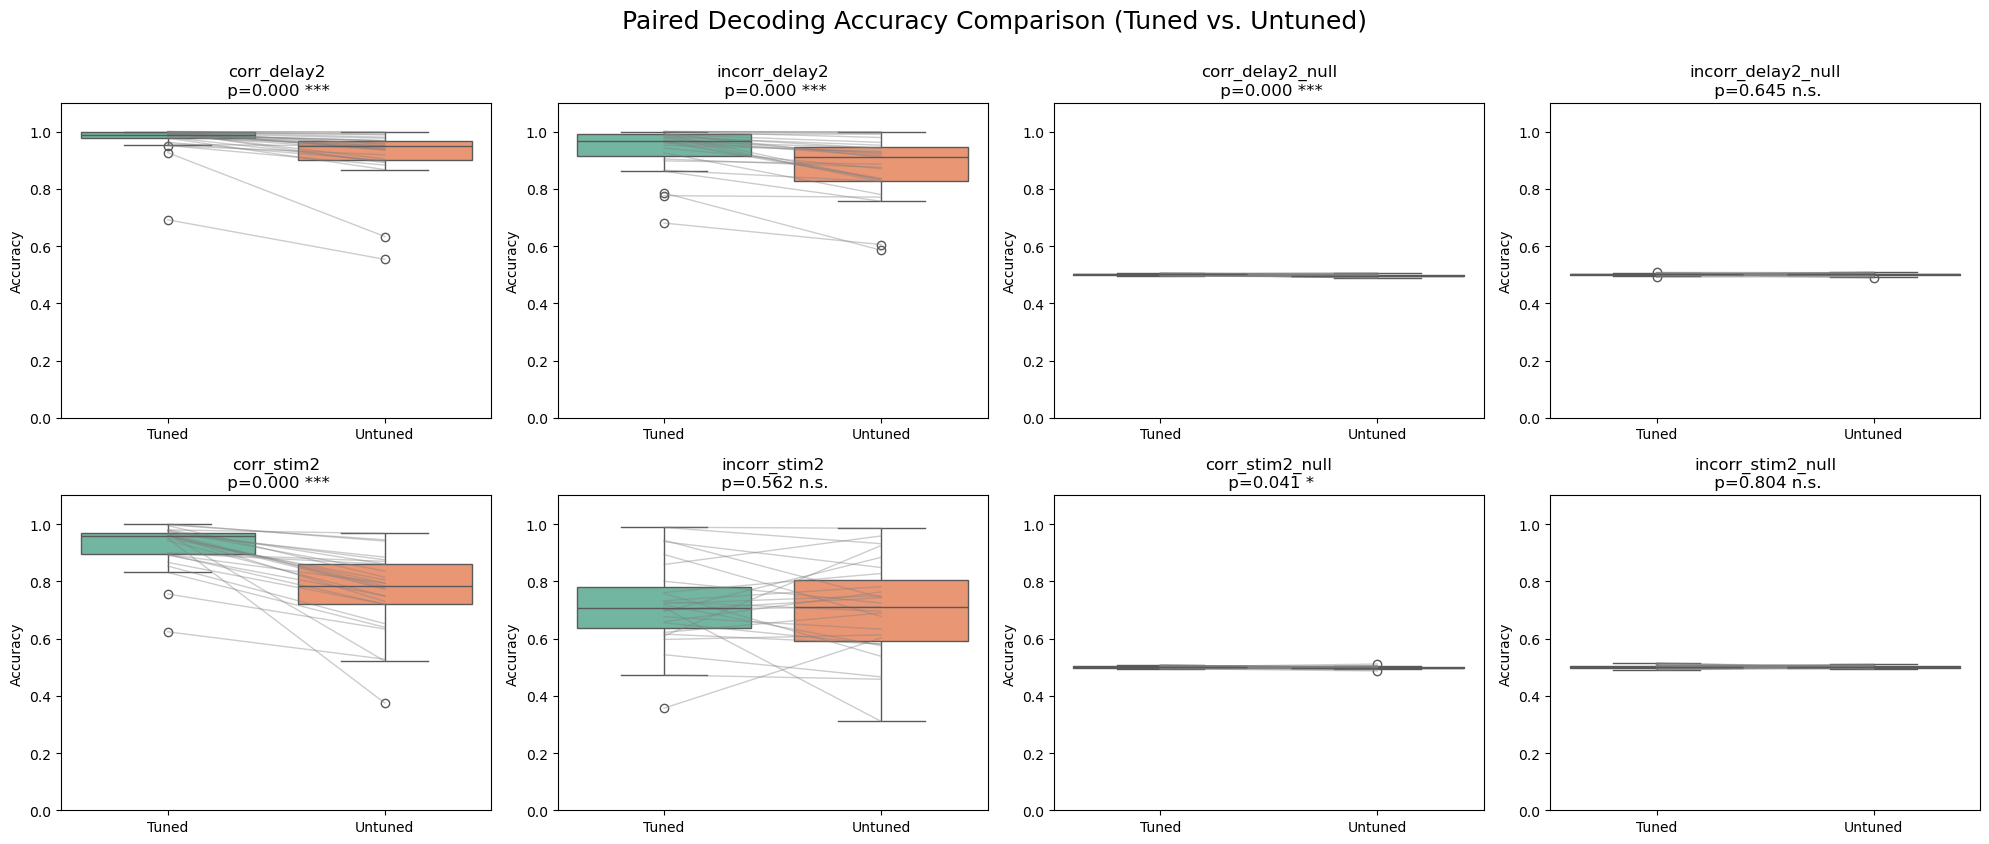

In [16]:
import seaborn as sns

# Define metrics to plot
metrics = [
    'acc_corr_delay2_mean',
    'acc_incorr_delay2_mean',
    'acc_corr_delay2_null_mean',
    'acc_incorr_delay2_null_mean',
    'acc_corr_stim2_mean',
    'acc_incorr_stim2_mean',
    'acc_corr_stim2_null_mean',
    'acc_incorr_stim2_null_mean'
]

# Plot setup
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    ax = axs[i]
    
    # Get paired data
    tuned_vals = decoding_results_tuned_df[metric].dropna().reset_index(drop=True)
    untuned_vals = decoding_results_untuned_df[metric].dropna().reset_index(drop=True)
    n_models = len(tuned_vals)
    
    data = {
        'Value': list(tuned_vals) + list(untuned_vals),
        'Condition': ['Tuned'] * n_models + ['Untuned'] * n_models,
        'Model': list(range(n_models)) * 2  # For paired lines
    }
    df_plot = pd.DataFrame(data)

    # Boxplot
    sns.boxplot(data=df_plot, x='Condition', y='Value', ax=ax, palette='Set2')
    # sns.stripplot(data=df_plot, x='Condition', y='Value', hue='Model', 
    #               dodge=True, ax=ax, linewidth=0.5, alpha=0.6, palette='gray', legend=False)

    # Draw lines between paired values
    for j in range(n_models):
        ax.plot([0, 1], [tuned_vals[j], untuned_vals[j]], color='gray', alpha=0.4, linewidth=1)

    # Mann-Whitney test
    stat, pval = scipy.stats.wilcoxon(tuned_vals, untuned_vals, alternative='two-sided')
    
    # Add p-value annotation
    star = ''
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = 'n.s.'

    ax.set_title(f'{metric.replace("_mean", "").replace("acc_", "")}\n p={pval:.3f} {star}')
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.suptitle('Paired Decoding Accuracy Comparison (Tuned vs. Untuned)', fontsize=18, y=1.05)
plt.show()
